In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent  # notebook lives in notebooks/, repo root is one up
sys.path.insert(0, str(REPO_ROOT))

from src.data.h5_reader import load_patient
import numpy as np
from src.data.ktgaussian import make_ktgaussian_mask
from src.utils.viz import plot_ktgaussian_mask, plot_mag_velocity
from src.data.dataset import _k2i_numpy
from src.baselines.cg_sense import cg_sense

In [2]:
patient_dir = REPO_ROOT / "Data/Center012/Philips_30T_Ingenia/P005"

d = load_patient(patient_dir)
kdata   = d['kdata']    # (Nv, Nt, Nc, SPE (Z), PE (Y), FE (X)) complex64
coilmap = d['coilmap']  # (Nc, SPE (Z), PE (Y), FE (X)) complex64
segmask = d['segmask']  # (SPE (Z), PE (Y), FE (X)) bool
params  = d['params']

kdata.shape, coilmap.shape, segmask.shape

((4, 25, 5, 20, 96, 92), (5, 20, 96, 92), (20, 96, 92))

In [3]:
# Create undersampling mask
R = 4
Nv, Nt, Nc, SPE, PE, FE = kdata.shape
mask = make_ktgaussian_mask(SPE=SPE, PE=PE, Nt=Nt, R=R, seed=42)
mask_tzy = mask.squeeze()  # (Nt, SPE, PE)
print(f"Mask shape: {mask_tzy.shape}") #(Nt, SPE, PE)
kdata_us = kdata * mask.astype(kdata.dtype)
print(f"Undersampled kdata shape: {kdata_us.shape}")

Mask shape: (25, 20, 96)
Undersampled kdata shape: (4, 25, 5, 20, 96, 92)


(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'frame t=0'}, xlabel='Z (SPE)', ylabel='Y (PE)'>,
        <Axes: title={'center': '$k_z$=10'}, xlabel='T (frame)', ylabel='Y (PE)'>],
       dtype=object))

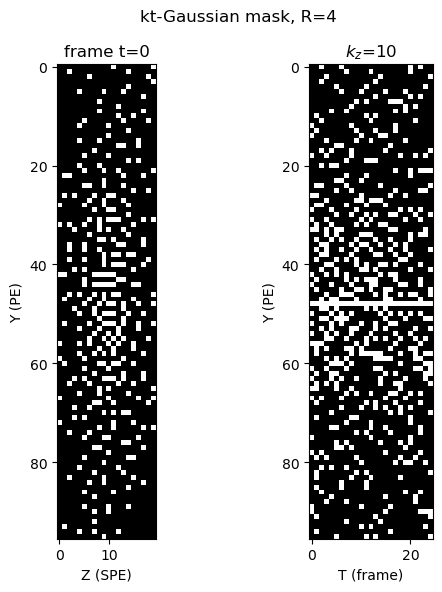

In [4]:
# Plot mask
plot_ktgaussian_mask(mask_tzy, R=R)

GT reconstruction shape: (4, 25, 20, 96, 92)


(<Figure size 1000x500 with 3 Axes>,
 array([<Axes: title={'center': 'magnitude'}, xlabel='Y (PE)', ylabel='X (FE, head-foot)'>,
        <Axes: title={'center': 'velocity norm  $v=|\\mathbf{v}|$'}, xlabel='Y (PE)', ylabel='X (FE, head-foot)'>],
       dtype=object))

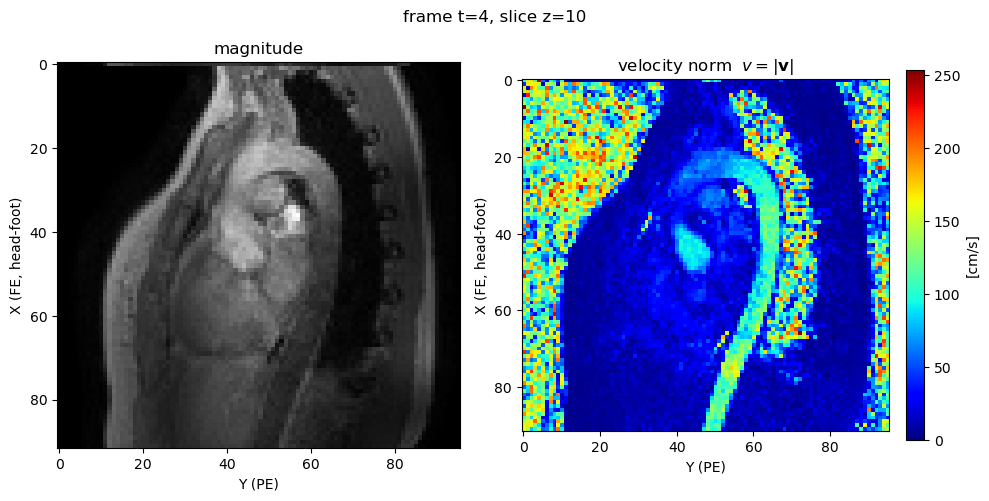

In [ ]:
#GT reconstruction
x_gt = np.sum(_k2i_numpy(kdata,ax=[-1,-2,-3]) * np.conj(coilmap),axis=-4)
print(f"GT reconstruction shape: {x_gt.shape}")  # (Nv, Nt, SPE, PE, FE)

plot_mag_velocity(x_gt, venc=params['VENC'], t0=4, vmax=160)

Zero-filled reconstruction shape: (4, 25, 20, 96, 92)


(<Figure size 1000x500 with 3 Axes>,
 array([<Axes: title={'center': 'magnitude'}, xlabel='Y (PE)', ylabel='X (FE, head-foot)'>,
        <Axes: title={'center': 'velocity norm  $v=|\\mathbf{v}|$'}, xlabel='Y (PE)', ylabel='X (FE, head-foot)'>],
       dtype=object))

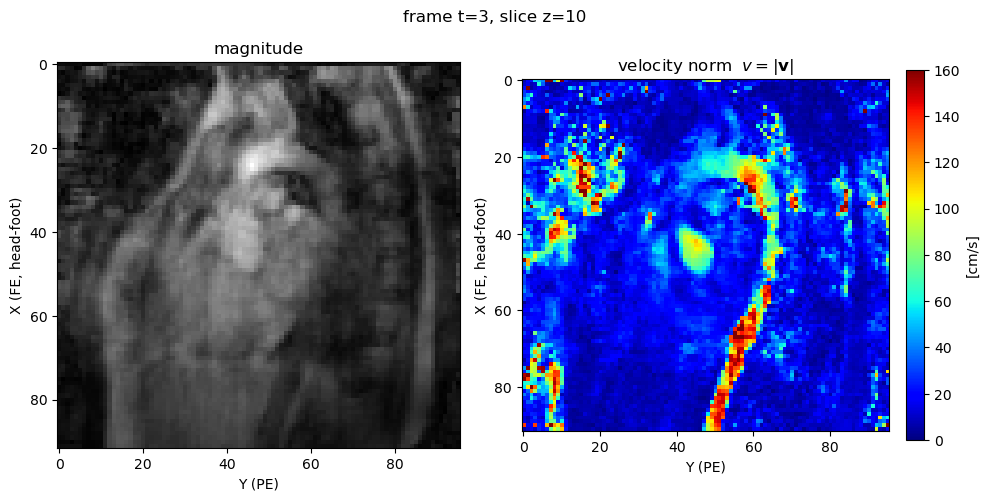

In [6]:
# Zero-filled reconstruction
x_zf = np.sum(_k2i_numpy(kdata_us,ax=[-1,-2,-3]) * np.conj(coilmap),axis=-4)
print(f"Zero-filled reconstruction shape: {x_zf.shape}")  # (Nv, Nt, SPE, PE, FE)

plot_mag_velocity(x_zf, venc=params['VENC'], t0=3, vmax=160)

In [7]:
x_cg, hist = cg_sense(kdata_us, coilmap, mask, n_iter=15, lam=1e-2,
                      verbose=True, return_history=True)
print(x_cg.shape, 'residual %.3f -> %.4f' % (hist[0], hist[-1]))


  cg iter   1/15  max rel. residual 2.790e-01
  cg iter   2/15  max rel. residual 1.263e-01
  cg iter   3/15  max rel. residual 6.491e-02
  cg iter   4/15  max rel. residual 5.421e-02
  cg iter   5/15  max rel. residual 3.628e-02
  cg iter   6/15  max rel. residual 2.767e-02
  cg iter   7/15  max rel. residual 1.950e-02
  cg iter   8/15  max rel. residual 1.515e-02
  cg iter   9/15  max rel. residual 1.124e-02
  cg iter  10/15  max rel. residual 8.883e-03
  cg iter  11/15  max rel. residual 6.454e-03
  cg iter  12/15  max rel. residual 5.232e-03
  cg iter  13/15  max rel. residual 4.205e-03
  cg iter  14/15  max rel. residual 3.435e-03
  cg iter  15/15  max rel. residual 2.670e-03
(4, 25, 20, 96, 92) residual 0.279 -> 0.0027


(<Figure size 1000x500 with 3 Axes>,
 array([<Axes: title={'center': 'magnitude'}, xlabel='Y (PE)', ylabel='X (FE, head-foot)'>,
        <Axes: title={'center': 'velocity norm  $v=|\\mathbf{v}|$'}, xlabel='Y (PE)', ylabel='X (FE, head-foot)'>],
       dtype=object))

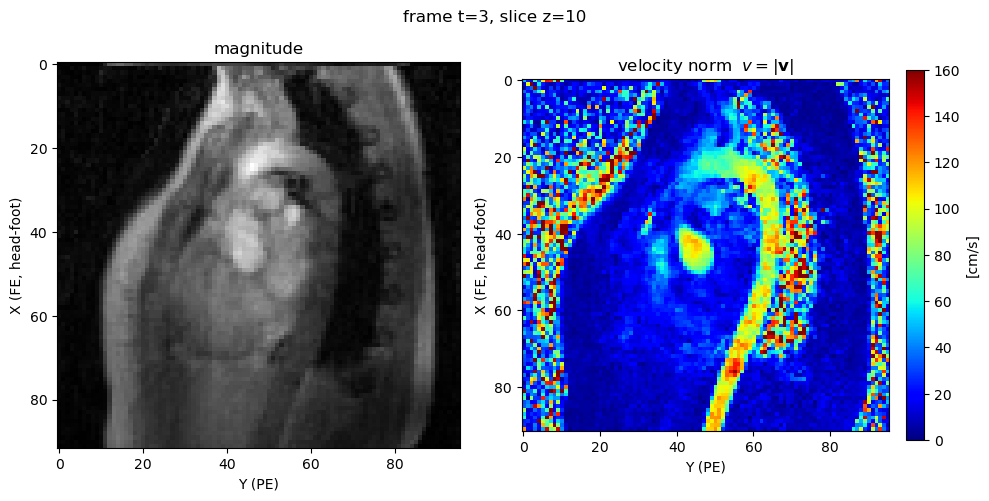

In [8]:
plot_mag_velocity(x_cg, venc=params['VENC'], t0=3, vmax=160)